혼동행렬로 성능평가

-학습 전에 로그변환 -> 공선성 체크-> 스케일링 -> 분석

분류 종속값이 여러개면 다중 분류 모델!


로지스틱 회귀분석...


종속변수는 다 명목형, 라벨링이라 해서 다 0 1 로 바꿔줘야함 나중에


로지스틱, 종속변수의 비율이 비슷해야함
비율이 안 맞으면 다운 샘플링, 업 샘플링...


- eda 끝나고
- 종속변수 라벨링 꼭 해줘야함!!!!!!!!!!!!!!
모형에 따라서 int 를 유지해야하는 겨우, category 여도 무방한 경우 나뉨

로지스틱회귀이기 떄문에 규제 방식 들어감~!

*VIFSelector 클래스 따로 가져오기

파이프라인을 통해서...vif,스케일링,학습 을 묶어놓을 수 있어
이추정기가 이 과정을 알아서 해주니까..
만약 파이프라인 없으며 정제한 데이터로 해야해...


# [LAB09] 지도학습 > 분류 > 01-로지스틱
종속변수가 0,1 로만 구성된 회귀분석
0은 음성, 1은 양성으로 본다면 둘 중 하나에 속할 확률을 구하는 것이므로 분류를 이해할 수 있음

## #01.준비작업
### [1] 패키지 가져오기

In [1]:
from hossam import *

import pandas as pd
from pandas import merge
from pandas import Series, DataFrame,concat
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

#로지스틱 회귀 모형
from sklearn.linear_model import LogisticRegression

#로지스틱 성능 평가 함수
from sklearn.metrics import confusion_matrix,roc_auc_score,roc_curve,accuracy_score,recall_score,precision_score,f1_score


#군집 시각화를 위한 참조
from scipy.spatial import ConvexHull

### [2] 데이터 가져오기
- 닥스훈트와 진돗개의 몸 길이와 키를 조사한 가상의 데이터

In [2]:
origin = load_data('dogs')
origin.head()

닥스훈트와 진돗개의 몸 길이와 키를 조사한 가상 데이터


,dog,length,height
0,d,55.010,29.270
1,d,59.010,29.390
2,d,56.530,28.500
3,d,53.660,28.500
4,d,49.670,31.970


### [2] 종속변수 타입 변환
- 로지스틱은 종속변수가 명목형 변수임

In [3]:
df=origin.astype({'dog':'category'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   dog     200 non-null    category
 1   length  200 non-null    float64 
 2   height  200 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.6 KB


## #02.데이터 품질 확인
### [1] 연속형 데이터 확인
#### 데이터 품질 확인 함수 정의

In [4]:
import numpy as np
from pandas import DataFrame, concat

def hs_describe(data, columns=None):
    num_columns = list(data.select_dtypes(include=np.number).columns)

    if not columns:
        columns = num_columns

    # 기술통계량 구하기
    desc = data[columns].describe().T

    # 각 컬럼별 결측치 수 (na_count) 추가
    na_counts = data[columns].isnull().sum()
    desc.insert(1, 'na_count', na_counts)

    # 결측치 비율 (na_rate) 추가
    desc.insert(2, 'na_rate', (na_counts / len(data)) * 100)

    # 추가 통계량 계산
    additional_stats = []

    for f in columns:
        # 숫자 타입이 아니라면 건너뜀
        if f not in num_columns:
            continue

        # 사분위수
        q1 = data[f].quantile(q=0.25)
        q3 = data[f].quantile(q=0.75)

        # 이상치 경계 (Tukey's fences)
        iqr = q3 - q1
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # 왜도
        skew = data[f].skew()

        # 이상치 개수 및 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # 분포 특성 판정 (왜도 기준)
        abs_skew = abs(skew)
        if abs_skew < 0.5:
            dist = "거의 대칭"
        elif abs_skew < 1.0:
            if skew > 0:
                dist = "약한 우측 꼬리"
            else:
                dist = "약한 좌측 꼬리"
        elif abs_skew < 2.0:
            if skew > 0:
                dist = "중간 우측 꼬리"
            else:
                dist = "중간 좌측 꼬리"
        else:
            if skew > 0:
                dist = "극단 우측 꼬리"
            else:
                dist = "극단 좌측 꼬리"

        # 로그변환 필요성 판정
        if abs_skew < 0.5:
            log_need = "낮음"
        elif abs_skew < 1.0:
            log_need = "중간"
        else:
            log_need = "높음"

        additional_stats.append({
            'field': f,
            'iqr': iqr,
            'up': up,
            'down': down,
            'outlier_count': outlier_count,
            'outlier_rate': outlier_rate,
            'skew': skew,
            'dist': dist,
            'log_need': log_need
        })

    additional_df = DataFrame(additional_stats).set_index('field')

    # 결과 병합
    result = concat([desc, additional_df], axis=1)

    return result


#### 데이터 품질 확인

In [5]:
hs_describe(df)

,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,up,down,outlier_count,outlier_rate,skew,dist,log_need
length,200.000,0,0.000,53.795,5.506,39.940,50.222,53.445,56.900,68.310,6.678,66.916,40.206,3,1.500,0.224,거의 대칭,낮음
height,200.000,0,0.000,41.675,10.036,22.760,31.965,43.785,51.185,55.870,19.220,80.015,3.135,0,0.000,-0.170,거의 대칭,낮음


- 결측치 및 이상치 없으며 로그변환 불필요

#### 데이터 분포 확인
- 최소,최대,중앙값을 확인하여, 데이터 분포가 크게 다르면 스케일링 권장
- 상자그림 시각화

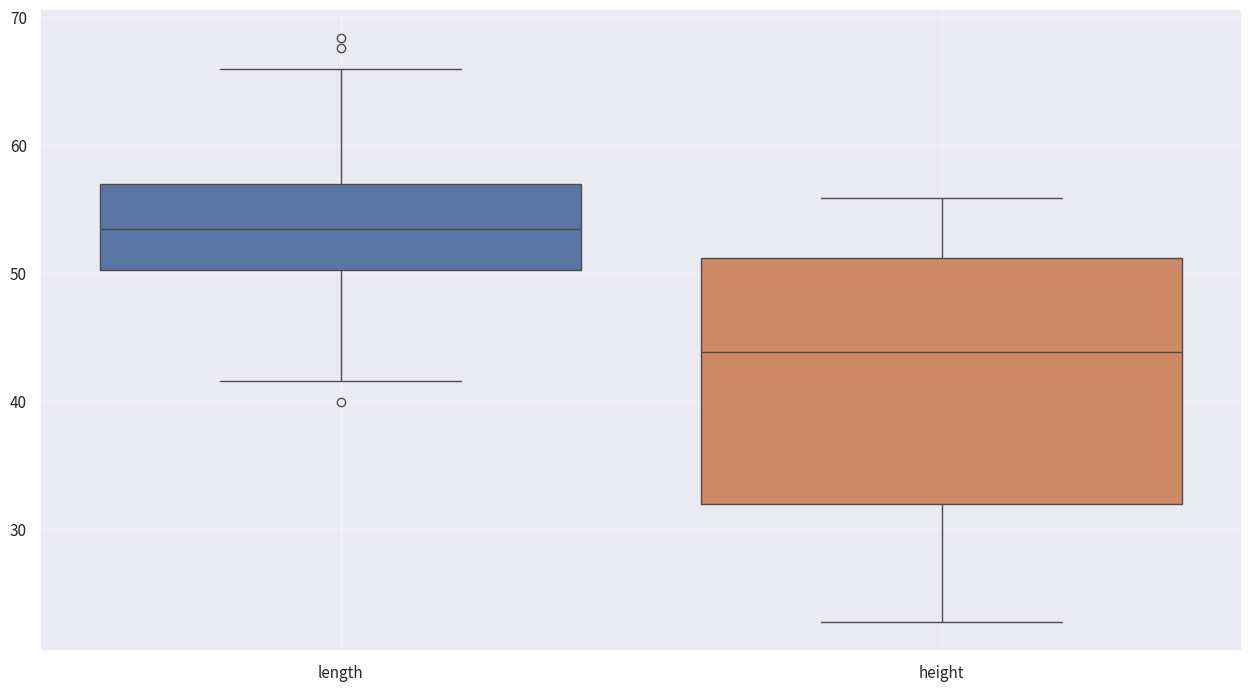

In [6]:
my_dpi = 100
figsize = (1280 / my_dpi, 720 / my_dpi)

fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.boxplot(data=origin, orient="v")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


### [2] 명목형 변수 확인
#### 명목형 변수 품질 확인 함수 정의

In [7]:

def category_describe(data, columns=None):
    num_columns = data.select_dtypes(include=np.number).columns

    if not columns:
        # 명목형(범주형) 컬럼 선택: object, category, bool 타입
        columns = data.select_dtypes(
            include=['object', 'category', 'bool']
        ).columns  # type: ignore

    result = []
    summary = []

    for f in columns:
        # 숫자형 컬럼은 건너뜀
        if f in num_columns:
            continue

        # 각 범주값의 빈도수 계산 (NaN 포함)
        value_counts = data[f].value_counts(dropna=False)

        # 범주별 빈도/비율 정보 추가 (category_table 기능)
        for category, count in value_counts.items():
            rate = (count / len(data)) * 100
            result.append({
                "변수": f,
                "범주": category,
                "빈도": count,
                "비율(%)": round(rate, 2)
            })

        if len(value_counts) == 0:
            continue

        # 최대/최소 범주 정보 추가 (category_describe 기능)
        max_category = value_counts.index[0]
        max_count = value_counts.iloc[0]
        max_rate = (max_count / len(data)) * 100

        min_category = value_counts.index[-1]
        min_count = value_counts.iloc[-1]
        min_rate = (min_count / len(data)) * 100

        summary.append({
            "변수": f,
            "최대_범주": max_category,
            "최대_비율(%)": round(max_rate, 2),
            "최소_범주": min_category,
            "최소_비율(%)": round(min_rate, 2)
        })

    return DataFrame(result), DataFrame(summary).set_index("변수")


#### 명목형 품질 확인

In [8]:
a, b = category_describe(df)
display(a)
display(b)


,변수,범주,빈도,비율(%)
0,dog,d,100,50.000
1,dog,j,100,50.000


,최대_범주,최대_비율(%),최소_범주,최소_비율(%)
변수,,,,
dog,d,50.000,j,50.000


- 로지스틱의 각 종속변수의 범주별 비율이 비슷해야 예측력이 일정 수준 유지

#### 명목형 분포 시각화

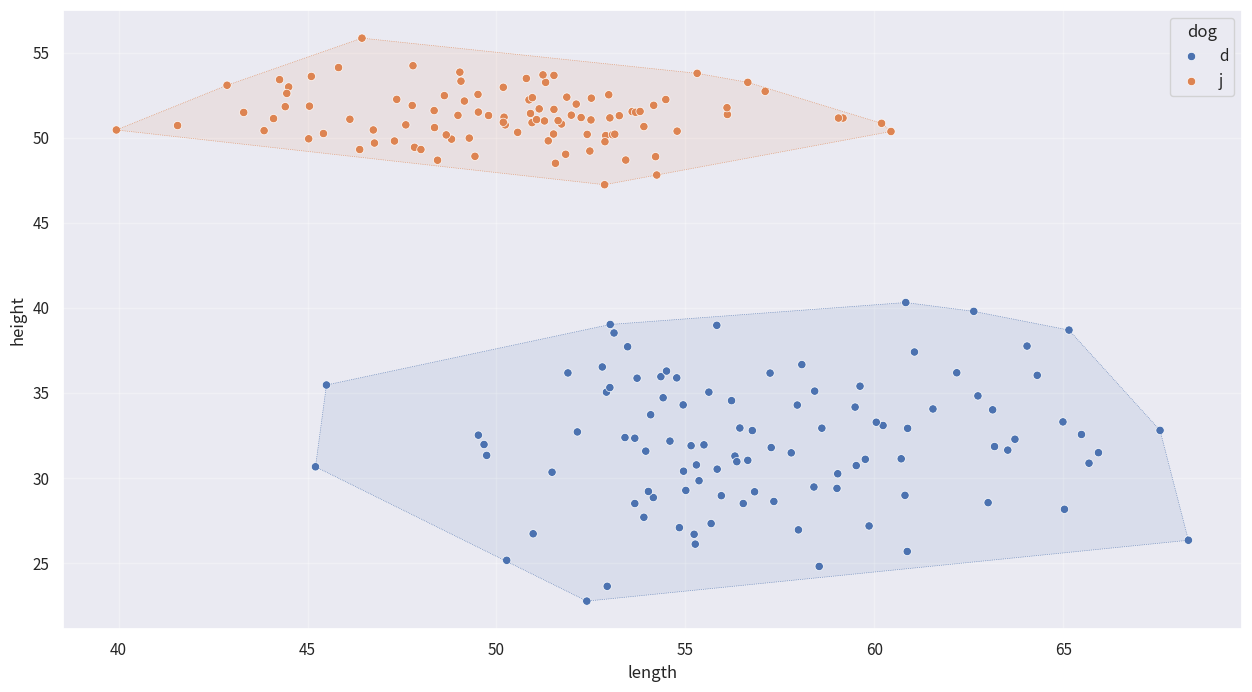

In [9]:
vdf = df.copy()
hue_field = "dog"
x_field = "length"
y_field = "height"
my_dpi = 100

figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# 군집별, 값의 종류별로 반복
for c in vdf[hue_field].unique():
    # 값의 종류별로 데이터프레임을 나눔
    df_c = vdf.loc[vdf[hue_field] == c, [x_field, y_field]]

    try:
        hull = ConvexHull(df_c)  # 마지막 좌표 이후 첫번째 좌표를 연결
        points = np.append(hull.vertices, hull.vertices[0])  # 시작점과 끝점 연결
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )
    except:
        pass

sb.scatterplot(data=vdf, x=x_field, y=y_field, hue=hue_field)

ax.grid(True, alpha=0.3)  # 배경 격자 표시
plt.tight_layout()
plt.show()
plt.close()


## #03.데이터 전처리
### [1] 종속변수 라벨링

In [10]:
df2 = df.copy()
df2['dog'] = df2['dog'].map({'d': 0, 'j': 1})

display(df2.head())
df2.info()


,dog,length,height
0,0,55.010,29.270
1,0,59.010,29.390
2,0,56.530,28.500
3,0,53.660,28.500
4,0,49.670,31.970


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   dog     200 non-null    category
 1   length  200 non-null    float64 
 2   height  200 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.6 KB


### [2] 훈련 검증 데이터 분리

In [11]:
df3 = df2

yname = "dog"
x = df3.drop(columns=[yname])
y = df3[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((150, 2), (50, 2), (150,), (50,))

## #04 로지스틱 회귀모형 적합
### [1] 로지스틱 주요 하이퍼 파라미터

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|-----------|--------|------|--------|--------------------|
| C | ⭐⭐⭐ | 정규화 강도의 역수 (작을수록 규제 강함 → 과적합 억제) | 1.0 | [0.01, 0.1, 1, 10, 100] |
| penalty | ⭐⭐⭐ | 정규화 방식 | 'l2' | ['l1', 'l2', 'elasticnet'] |
| solver | ⭐⭐⭐ | 최적화 알고리즘 (penalty와 강하게 연동) | 'lbfgs' | ['liblinear', 'lbfgs', 'saga'] |
| max_iter | ⭐⭐ | 최대 반복 횟수 (수렴 실패 방지) | 100 | [100, 300, 500, 1000] |
| l1_ratio | ⭐⭐ | ElasticNet에서 L1 비율 (penalty='elasticnet'일 때만 사용) | None | [0.1, 0.3, 0.5, 0.7, 0.9] |
| class_weight | ⭐⭐ | 클래스 불균형 보정 | None | None / 'balanced' |


In [13]:
pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs.fit(x_train, y_train)

estimator = gs.best_estimator_
estimator


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.01, random_state=52))])

### [2] 검증 데이터를 통한 추정값 생성

In [14]:
y_pred = estimator.predict(x_test)
y_pred

array([1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1], dtype=int64)

### [3] 결과 시각화

In [15]:
df4 = x_test.copy()
df4['y_test'] = y_test

df4['y_pred'] = y_pred
df4.head()



,length,height,y_test,y_pred
119,54.480,52.260,1,1
62,59.030,30.250,0,0
132,55.310,53.800,1,1
114,42.870,53.100,1,1
104,56.110,51.380,1,1


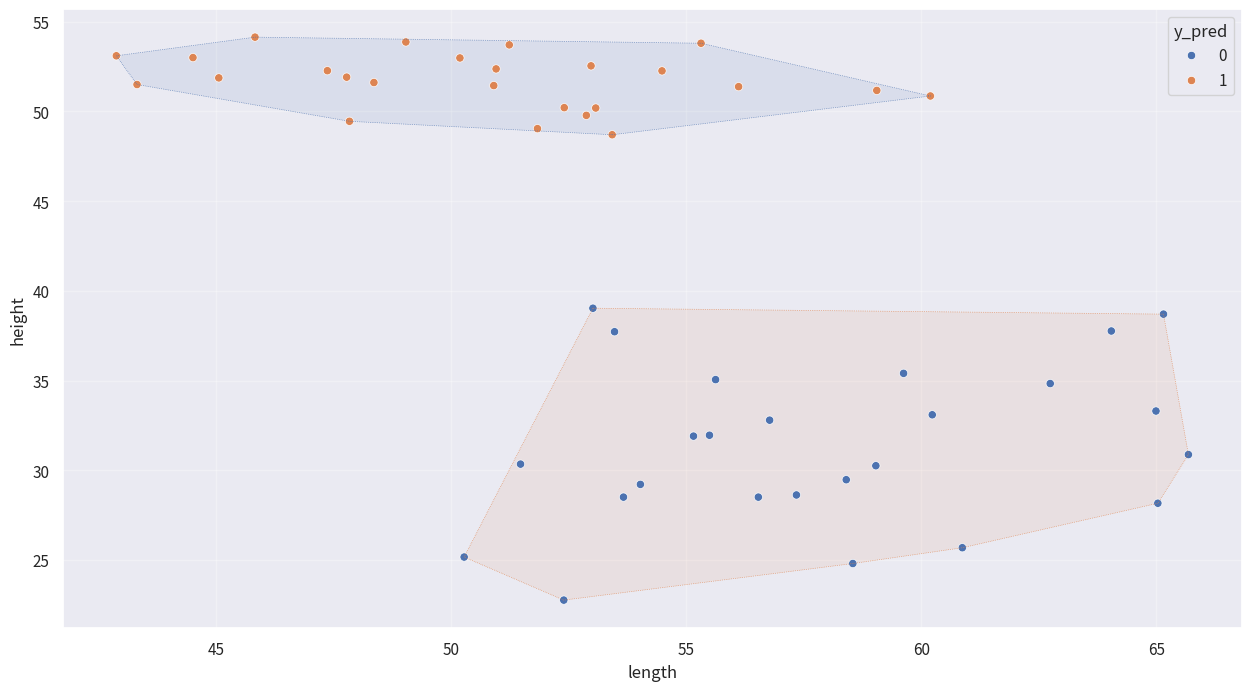

In [16]:
vdf = df4.copy()
hue_field = "y_pred"
x_field = "length"
y_field = "height"

figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# 군집별, 값의 종류별로 반복
for c in vdf[hue_field].unique():
    # 값의 종류별로 데이터프레임을 나눔
    df_c = vdf.loc[vdf[hue_field] == c, [x_field, y_field]]

    try:
        hull = ConvexHull(df_c)  # 마지막 좌표 이후 첫번째 좌표를 연결
        points = np.append(hull.vertices, hull.vertices[0])  # 시작점과 끝점 연결
        ax.plot(df_c.iloc[points, 0], df_c.iloc[points, 1], linewidth=0.5, linestyle=":")
        ax.fill(df_c.iloc[points, 0], df_c.iloc[points, 1], alpha=0.1)
    except:
        pass

sb.scatterplot(data=vdf, x=x_field, y=y_field, hue=hue_field)

ax.grid(True, alpha=0.3)  # 배경 격자 표시
plt.tight_layout()
plt.show()
plt.close()


## #05 새로운 정보를 통한 예측 수행
- 훈련 모델에게 임의의  height 와 length 값을 투입했을 때 어떤 종으로 판별하는지 확인

In [17]:
input_df = DataFrame({
    'length': [47, 39, 52],
    'height': [23, 42, 49]
})

input_df['y_pred'] = estimator.predict(input_df)
input_df


,length,height,y_pred
0,47,23,0
1,39,42,1
2,52,49,1
